# Read H-Reflex App Data Files (.hrs1 and .hrs2)

This notebook reads and visualizes data from the **H-Reflex Behavior App** binary data files:

- **`.hrs1`**  EMG Characterization stage data (Stage S1): contains trial-initiation monitored signals, binned EMG, and grand means.
- **`.hrs2`** MH Recruitment Curve stage data (Stage S2): contains peri-stimulus trial waveforms with stimulation amplitudes.

Both file types also store raw EMG data blocks (differential, filtered, absolute-valued signals).

The binary format is based on the `FileIO_Helpers` serialization from the `hreflex_txbdc` package.

# Section 1: Binary File Reader Utilities

In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import display
from helpers import (
    # File readers + summaries
    read_hrs1, read_hrs2, find_hrs_files,
    print_hrs1_summary, print_hrs2_summary,
    # Core HRS2 analysis (same as main notebooks)
    plot_amplitude_distribution, plot_background_emg_views,
    plot_hrs2_analysis, plot_hrs2_trials,
    classify_trials, get_trial_window,
    detect_stim_onset, get_trial_context_window,
    detect_and_correct_failed_trials,
    compute_snr_analysis, compute_mra_snr_analysis,
    # Post-hoc background analysis
    analyze_global_background,
    # Timeline + H:M summary
    plot_actual_trial_timeline,
    split_trials_by_polarity, plot_hm_ratio_summary,
    # Constants
    SAMPLE_RATE, BIN_DURATION_MS, BIN_SAMPLES, TRIAL_RECORD_MS,
    STIM_ONSET_THRESHOLD, STIM_END_THRESHOLD,
)

print("Helpers loaded.")
print(f"  App constants: SAMPLE_RATE={SAMPLE_RATE} Hz | BIN={BIN_DURATION_MS} ms ({BIN_SAMPLES} samples) | TRIAL_RECORD={TRIAL_RECORD_MS} ms")
print(f"  Stim thresholds: onset >= {STIM_ONSET_THRESHOLD} V | end < {STIM_END_THRESHOLD} V")

Helpers loaded.
  App constants: SAMPLE_RATE=5000.0 Hz | BIN=50 ms (250 samples) | TRIAL_RECORD=100 ms
  Stim thresholds: onset >= 4.5 V | end < 1.9 V


# Section 2: Read and Explore the HRS1 File (EMG Characterization)

# Section 1b: Auto-Detect Recording Files

Set `recording_dir` to the path of your recording folder.  
The `.hrs1` and `.hrs2` files will be found automatically.

In [36]:
# ---- Set your recording directory here ----
# Set to the folder that contains your .hrs1 (and optionally .hrs2) files.
#
# Latest recordings (HRS2 v5, may include background_emg_mean + background_bins):
#   HRPILOT-17_EMG_CHARACTERIZATION_5-12-2026  -- HRS2 v5, 5 kHz, with background_bins
#   D1_5KHZ_HRPILOT16_B_5-11-26               -- HRS2 v5, 5 kHz, background_emg_mean only
#
# New-format HRPILOT recordings (HRS1 includes sample_rate field, HRS2 v4):
#   D1_HRPILOT16_A_5-11-26                    -- 10 kHz, HRS2 v4
#   D1_HRPILOT16_B_5-11-26                    -- 10 kHz, HRS2 v4
#   HRPILOT-16-CONFIGA_RECRUITMENTCURVE_      -- first recruitment curve  (HRS2 v2)
#   HRPILOT-16-CONFIGA_2ND_RECRUITMENTCURVE_  -- second recruitment curve (HRS2 v3, unipolar)
#   HRPILOT-16_A_CONTROL_MODE_5-5-26          -- control-mode session     (HRS2 v4)
#
# Legacy polarity / hour-test recordings (no sample_rate in HRS1 header):
#   Polarity_Tests/HR-08-POLARITY_TEST_CORRECT   -- electrodes attached correctly
#   Polarity_Tests/HR-08-POLARITY_TEST_FLIPPED_  -- electrodes attached flipped
#   Polarity_Tests/HR-08-HOUR_TEST_              -- HRS1 only (no HRS2 file)

recording_dir = "D3_HRPILOT-16_200US_15KHZ_A_5-20-26"
recording_sample_rate = None  # Set to e.g. 5000.0 or 10000.0 to override; None = auto-detect from HRS1 header

hrs1_path, hrs2_path = find_hrs_files(recording_dir)
print(f"Recording directory: {recording_dir}")
print(f"  HRS1 file: {os.path.basename(hrs1_path)}")
if hrs2_path is not None:
    print(f"  HRS2 file: {os.path.basename(hrs2_path)}")
else:
    print("  HRS2 file: not found â HRS2 sections will be skipped")


Recording directory: D3_HRPILOT-16_200US_15KHZ_A_5-20-26
  HRS1 file: D3_HRPILOT-16_200US_15KHZ_A_5-20-26_20260520T174454.hrs1
  HRS2 file: D3_HRPILOT-16_200US_15KHZ_A_5-20-26_20260520T174528.hrs2


In [37]:
# ---- Read the HRS1 file (auto-detected) ----
hrs1_header, hrs1_trials, hrs1_emg_blocks = read_hrs1(hrs1_path)
print_hrs1_summary(hrs1_header, hrs1_trials, hrs1_emg_blocks, hrs1_path)

=== HRS1 Header ===
  File:               D3_HRPILOT-16_200US_15KHZ_A_5-20-26_20260520T174454.hrs1
  File version:       1
  Subject ID:         D3_HRPILOT-16_200US_15KHZ_A_5-20-26
  Session datetime:   2026-05-20 17:44:54.600375
  Stage name:         S1
  Stage description:  EMG Characterization
  Stage type:         0
  Trial init uV min:  15.0
  Trial init uV max:  300.0
  Trial init phase min ms: 2200
  Trial init phase max ms: 2700
  Bin duration ms:    50
  Sample rate:        5000.0 Hz
  Trials/hr data: centre=66.01 µV, elapsed=0.005 h, 20 window sizes

  Trials found:       2
  EMG data blocks:    996

=== First Trial ===
  End datetime:       2026-05-20 17:45:06.117291
  Start index:        0
  Grand mean:         95.5321
  Bins count:         47
  Monitored signal N: 35250

=== First EMG Block ===
  Channel names:      ['CH10', 'CH12', 'ADC1', 'ADC2', 'ADC3', 'ADC4', 'ADC5']
  Raw channels:       7 x 128 samples
  Diff samples:       128
  Filtered samples:   128
  Abs sample

# Section 3: Read and Explore the HRS2 File (MH Recruitment Curve)

In [38]:
# ---- Read the HRS2 file (auto-detected) ----
if hrs2_path is None:
    print("No HRS2 file found — skipping HRS2 read.")
    hrs2_header, hrs2_trials, hrs2_emg_blocks = None, [], []
else:
    hrs2_header, hrs2_trials, hrs2_emg_blocks = read_hrs2(hrs2_path)
    print_hrs2_summary(hrs2_header, hrs2_trials, hrs2_emg_blocks, hrs2_path)

=== HRS2 Header ===
  File:               D3_HRPILOT-16_200US_15KHZ_A_5-20-26_20260520T174528.hrs2
  File version:       7  (v7)
  Subject ID:         D3_HRPILOT-16_200US_15KHZ_A_5-20-26
  Session start time: 2026-05-20 17:45:28.958657
  Stage name:         S2
  Stage description:  Mh Recruitment Curve
  Stage type:         1

  Trials found:       1
  EMG data blocks:    2232
  Stim polarity:      1 normal, 0 reversed

=== First EMG Block ===
  Channel names:  ['CH10', 'CH12', 'ADC1', 'ADC2', 'ADC3', 'ADC4', 'ADC5']
  Raw channels:   7 x 192 samples
  Diff samples:   192


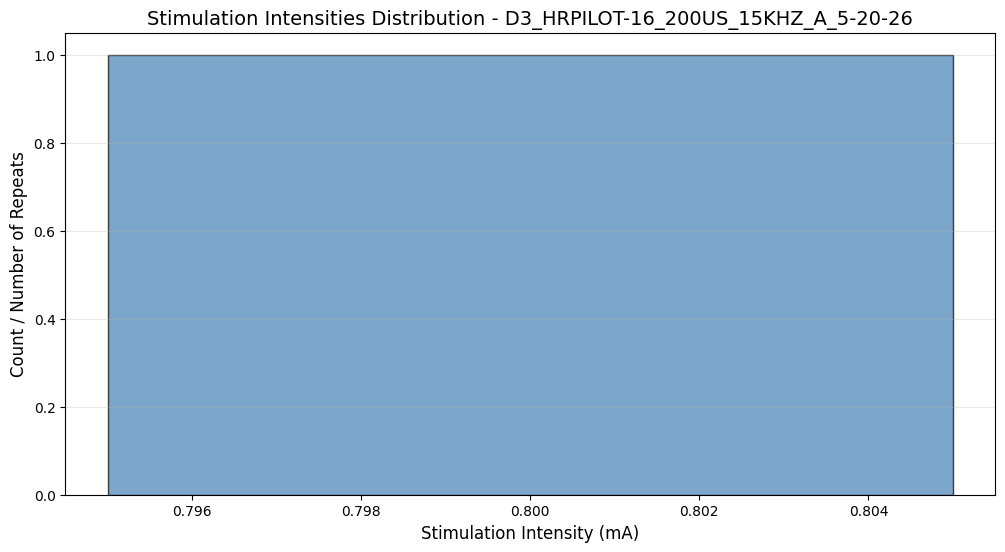

1 trials used stored bins  |  0 trials reconstructed from emg_blocks.


In [39]:
# ---- Histogram of stimulation intensities ----
plot_amplitude_distribution(hrs2_trials, hrs2_header)

# ---- "Most recent background" + "Background EMG Level" plots ----
# Mirrors the H-Reflex App recruitment-curve trial plot widgets.
# Uses stored background_bins / background_emg_mean from each trial (file_version >= 5);
# falls back to reconstructing from emg_blocks for older files.
plot_background_emg_views(hrs2_trials, hrs2_emg_blocks, monitoring_window_ms=2500,
                          sample_rate=recording_sample_rate or hrs1_header.sample_rate,
                          bin_duration_ms=hrs1_header.bin_duration_ms)

Actual trial timeline (1 trials)
  Recording span : 0.0 s  (0.000 h)
  Trial rate     : nan trials / hour


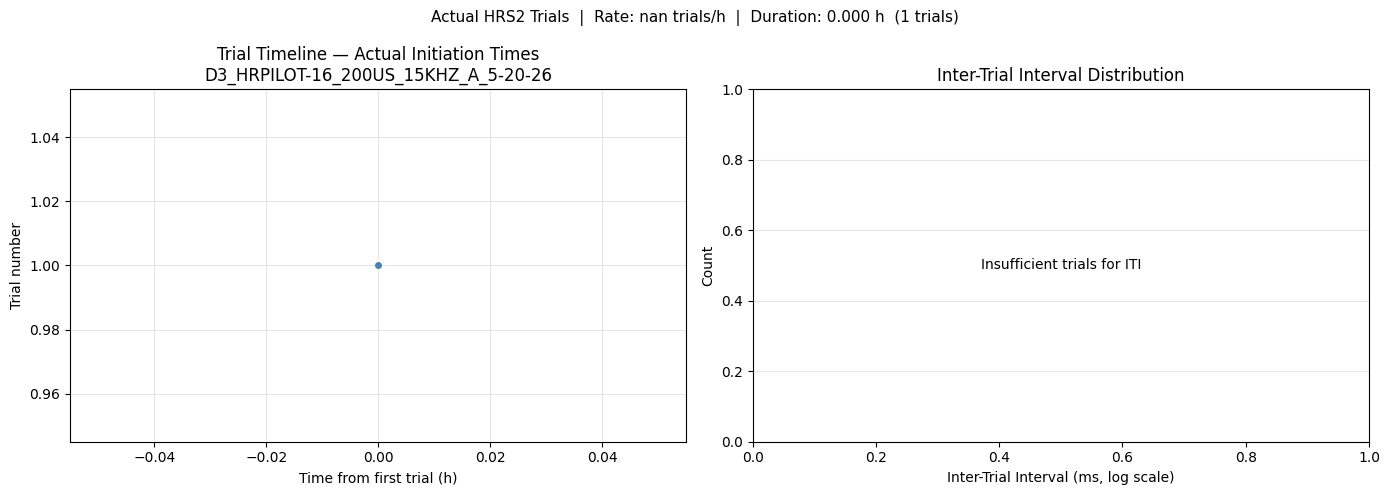

In [40]:
# ---- Actual trial timeline + ITI distribution + trial rate ----
plot_actual_trial_timeline(hrs2_trials, header=hrs2_header)

In [41]:
# ---- Analysis Configuration ----
PRE_PLOT_MS  = 15     # ms before stim onset — individual trial view
POST_PLOT_MS = 15    # ms after  stim onset — individual trial view
N_PER_PAGE   = 6    # subplots per page (2 rows × 3 cols)

# M/H wave windows (ms relative to stim onset)
M_WAVE_START_MS = 3
M_WAVE_END_MS   = 5.5   
H_WAVE_START_MS = 9
H_WAVE_END_MS   = 13

PRE_AVG_MS  = 15     # ms before stim onset — averaged waveform view
POST_AVG_MS = 15    # ms after  stim onset — averaged waveform view

In [42]:
'''# ---- Failed Trial Detector & Realignment ----
# Classifies all trials for ADC-sync failures, realigns each failed trial to the
# true stim onset found via the ADC pulse stream, and shows interactive viewers.
trial_report, failed, passed, realigned = detect_and_correct_failed_trials(
    hrs2_trials, hrs2_header, hrs2_emg_blocks,
    pre_ms=PRE_PLOT_MS, post_ms=POST_PLOT_MS,
    m_start_ms=M_WAVE_START_MS, m_end_ms=M_WAVE_END_MS,
    h_start_ms=H_WAVE_START_MS, h_end_ms=H_WAVE_END_MS,
    sample_rate=recording_sample_rate or hrs1_header.sample_rate,
)'''

'# ---- Failed Trial Detector & Realignment ----\n# Classifies all trials for ADC-sync failures, realigns each failed trial to the\n# true stim onset found via the ADC pulse stream, and shows interactive viewers.\ntrial_report, failed, passed, realigned = detect_and_correct_failed_trials(\n    hrs2_trials, hrs2_header, hrs2_emg_blocks,\n    pre_ms=PRE_PLOT_MS, post_ms=POST_PLOT_MS,\n    m_start_ms=M_WAVE_START_MS, m_end_ms=M_WAVE_END_MS,\n    h_start_ms=H_WAVE_START_MS, h_end_ms=H_WAVE_END_MS,\n    sample_rate=recording_sample_rate or hrs1_header.sample_rate,\n)'

In [43]:
# ---- Silent Failed Trial Filter ----
# Detects and removes failed trials from hrs2_trials with no plots or widgets.
# Run this cell instead of (or after) the interactive detector above when you
# just want a clean trial list for downstream analysis.
_report_s, _failed_s, _passed_s, _ = detect_and_correct_failed_trials(
    hrs2_trials, hrs2_header, hrs2_emg_blocks,
    pre_ms=PRE_PLOT_MS, post_ms=POST_PLOT_MS,
    m_start_ms=M_WAVE_START_MS, m_end_ms=M_WAVE_END_MS,
    h_start_ms=H_WAVE_START_MS, h_end_ms=H_WAVE_END_MS,
    sample_rate=recording_sample_rate or hrs1_header.sample_rate,
    silent=True,
)

_passed_idx = {r['idx'] for r in _passed_s}
hrs2_trials = [t for i, t in enumerate(hrs2_trials) if i in _passed_idx]

print(f"Failed trials removed : {len(_failed_s)}")
print(f"Trials remaining      : {len(hrs2_trials)}")


File version : 7  (pre-computed fields used)
Total trials : 1
Passed       : 1
Failed       : 0

No failed trials — all trials passed ADC-sync check.
Failed trials removed : 0
Trials remaining      : 1


In [ ]:
# ---- HRS2 Analysis: Averaged Waveforms + Recruitment Curve (all trials) ----
# Polarity toggle built in — both Normal (0) and Reversed (1) shown side by side.
plot_hrs2_analysis(
    hrs2_trials, hrs2_header,
    pre_avg_ms=PRE_AVG_MS, post_avg_ms=POST_AVG_MS,
    n_per_page=N_PER_PAGE,
    m_start_ms=M_WAVE_START_MS, m_end_ms=M_WAVE_END_MS,
    h_start_ms=H_WAVE_START_MS, h_end_ms=H_WAVE_END_MS,
    sample_rate=recording_sample_rate or hrs1_header.sample_rate,
)

Loaded 8 amplitude groups across 2 page(s).
Double-click a subplot to zoom in. Ctrl-click to select multiple signals.


Output()

In [11]:
# ---- HRS2 Trial Viewer: Interactive Per-Trial Grid + Zoom ----
plot_hrs2_trials(
    hrs2_trials, hrs2_header,
    pre_plot_ms=PRE_PLOT_MS, post_plot_ms=POST_PLOT_MS,
    n_per_page=N_PER_PAGE,
    m_start_ms=M_WAVE_START_MS, m_end_ms=M_WAVE_END_MS,
    h_start_ms=H_WAVE_START_MS, h_end_ms=H_WAVE_END_MS,
    sample_rate=recording_sample_rate or hrs1_header.sample_rate,
)

Loaded 363 trials across 61 page(s)  — dual-polarity session: 363 normal, 396 reversed.
Sample rate: 5000 Hz  |  ms/sample: 0.2000
Stim waveform: available
Double-click a subplot to zoom in, or use the dropdown + 'View trial' button.


TraitError: The 'visibility' trait of a Layout instance expected any of ['visible', 'hidden', 'inherit', 'initial', 'unset'] (case-insensitive) or None, not the str ''.

# Section 7: Signal-to-Noise Ratio Analysis

For each trial, three RMS-based SNR values are computed relative to the **RMS of the pre-stimulus background**:

| SNR metric | Formula |
|---|---|
| **SNR_M** | RMS(M-wave window) / RMS(pre-stim BG) |
| **SNR_H** | RMS(H-wave window) / RMS(pre-stim BG) |
| **SNR_H:M** | (RMS_H / RMS_M) / RMS(pre-stim BG) |

Adjust `BG_PRE_MS` to change the background window length.

SNR Analysis — TEST1_HR-16_200USPULSE_5-18-26
  M window : 3–5.5 ms
  H window : 9–13 ms
  BG window: -15–0 ms (pre-stim)

Metric                 n      Mean    Median        SD      CV
--------------------------------------------------------------
  SNR_M  (M/BG)      759     1.294     0.847     1.689   1.305
  SNR_H  (H/BG)      759     1.330     0.861     2.347   1.765
  SNR_HM (H:M/BG)    759     0.025     0.004     0.132   5.242


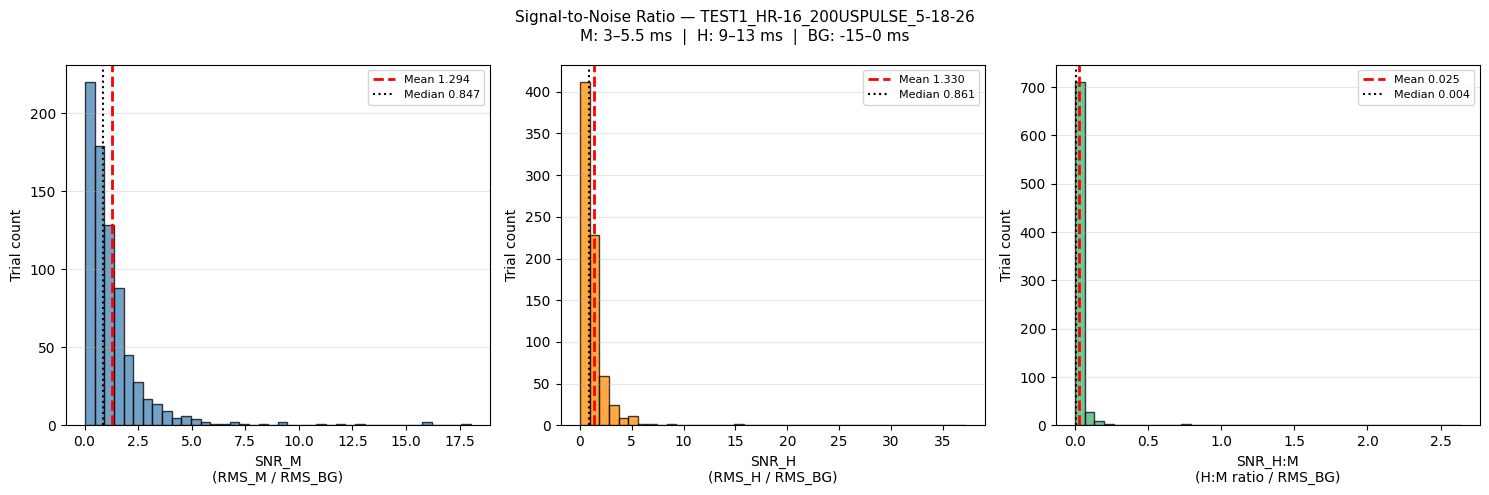

In [20]:
# ---- Section 7: Signal-to-Noise Ratio ----
# Background window length (ms before stim onset).
BG_PRE_MS = 15.0

snr_results = compute_snr_analysis(
    hrs2_trials, hrs2_header,
    m_start_ms=M_WAVE_START_MS, m_end_ms=M_WAVE_END_MS,
    h_start_ms=H_WAVE_START_MS, h_end_ms=H_WAVE_END_MS,
    bg_pre_ms=BG_PRE_MS,
    sample_rate=recording_sample_rate or hrs1_header.sample_rate,
)

# Section 8: Signal-to-Noise Ratio Analysis (Mean Rectified Average)

Same SNR analysis as Section 7, but using **Mean Rectified Average (MRA)** — `mean(|signal|)` — instead of RMS.

| SNR metric | Formula |
|---|---|
| **MRA-SNR_M** | MRA(M-wave window) / MRA(pre-stim BG) |
| **MRA-SNR_H** | MRA(H-wave window) / MRA(pre-stim BG) |
| **MRA-SNR_H:M** | (MRA_H / MRA_M) / MRA(pre-stim BG) |

MRA-SNR Analysis — TEST1_HR-16_200USPULSE_5-18-26
  M window : 3–5.5 ms
  H window : 9–13 ms
  BG window: -15–0 ms (pre-stim)

Metric                   n      Mean    Median        SD      CV
----------------------------------------------------------------
  MRA-SNR_M  (M/BG)    759     1.571     0.992     2.180   1.388
  MRA-SNR_H  (H/BG)    759     1.532     0.958     2.709   1.768
  MRA-SNR_HM (H:M/BG)   759     0.033     0.006     0.172   5.176


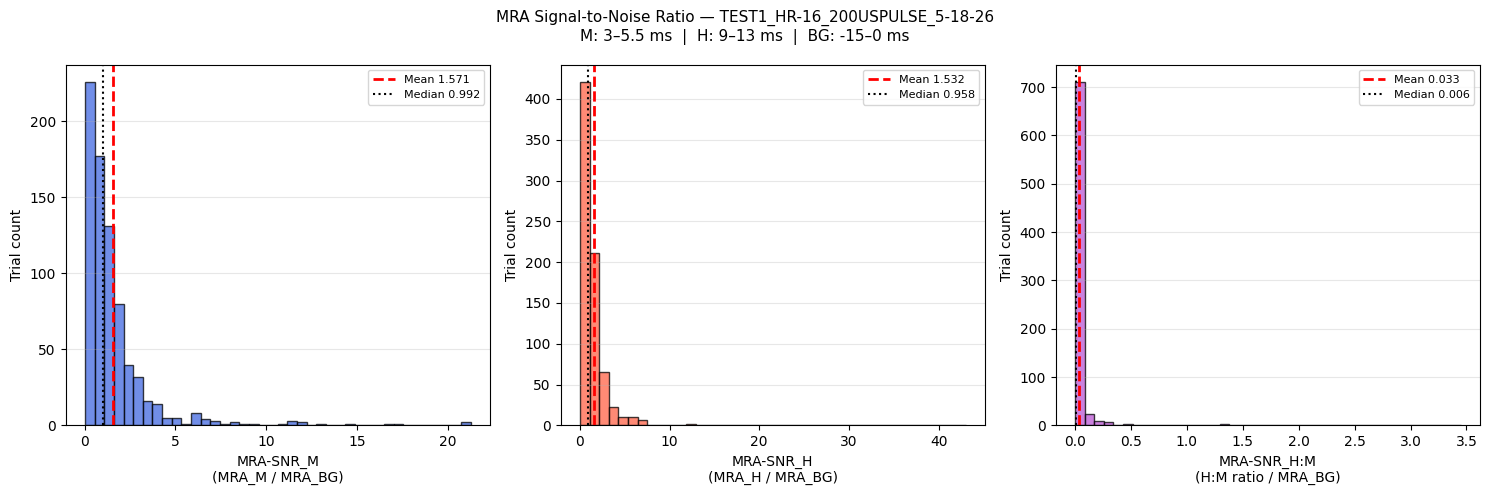

In [21]:
# ---- Section 8: MRA Signal-to-Noise Ratio ----
# Same as Section 7 but uses Mean Rectified Average (mean |signal|) instead of RMS.
mra_snr_results = compute_mra_snr_analysis(
    hrs2_trials, hrs2_header,
    m_start_ms=M_WAVE_START_MS, m_end_ms=M_WAVE_END_MS,
    h_start_ms=H_WAVE_START_MS, h_end_ms=H_WAVE_END_MS,
    bg_pre_ms=BG_PRE_MS,
    sample_rate=recording_sample_rate or hrs1_header.sample_rate,
)

# Section 4: Post-Hoc Background EMG Analysis

Reconstruct the continuous abs-EMG signal from HRS2 EMG blocks, blank around each stimulation event, compute background statistics, extract per-trial pre-stim grand means, and run the direct background sweep.

**Steps:**
1. **4a** — Sort and stitch all HRS2 EMG blocks into one continuous signal.
2. **4b** — Build a blank mask that suppresses samples within ±[`blank_pre_ms`, `blank_post_ms`] of every stimulation event.
3. **4c** — Compute global background EMG statistics from the non-blanked signal.
4. **4d** — Extract each trial's pre-stim background grand mean and plot the distribution.
5. **4e** — Run the direct per-trial background sweep (EMG window width vs matched trials).

In [22]:
# ---- Section 4: Post-hoc background EMG analysis ----
state = analyze_global_background(
    hrs2_trials, hrs2_emg_blocks, hrs2_header,
    sample_rate=recording_sample_rate or hrs1_header.sample_rate,
    blank_pre_ms=5, blank_post_ms=20,
    min_valid_frac=0.7,
)

Section 4a: Reconstructing continuous signal from HRS2 EMG blocks
  Blocks stitched : 97,177
  Total samples   : 5,614,416
  Duration        : 1122.9 s  (18.7 min)
  OE sample range : 1779136965664 – 1779142580080
  Gap samples     : 1,813,385  (32.299% of total)

Section 4b: Building blank mask around stimulation events
Blank mask: 0 events -> 0 samples blanked (0.0000 fraction)
  Stim events mapped  : 0 of 759
  Unmapped (no onset) : 759
  Non-blanked samples : 5,614,416  (100.0%)

Section 4c: Background EMG statistics (non-blanked samples)
  n       : 5,614,416
  Mean    : 117.198 µV
  Std     : 193.443 µV
  Q1      : 0.000 µV
  Median  : 26.950 µV
  Q3      : 166.109 µV

Section 4d: Per-trial pre-stim background grand means
  Trials : 759  (failed reconstruction: 0)
  Min=7.96  Q1=157.37  Median=182.22  Q3=212.05  Max=356.47
  Recorded thresholds (mean): [46.31, 393.08] µV


# Section 4b: Manual EMG Activity Bins

Classify trials into user-defined pre-stim EMG level bins using the per-trial grand means
computed in Section 4a (`state['trial_bg_gm']`).

**Edit `EMG_BINS`** below to set your own `(low_µV, high_µV)` ranges — as many bins as needed.
Gaps between bins are allowed; a trial is assigned to the **first** bin whose interval
`[lo, hi)` contains its background grand mean.

**Outputs:**
- **4b** — bin definition + trial count summary
- **4c** — combined viewer: averaged waveforms for all bins overlaid + H:M box plot; polarity toggle
- **4d** — per-bin interactive viewer: full `plot_hrs2_analysis` + `plot_hrs2_trials` for the selected bin + polarity
- **4e** — numeric statistics table (MRA, H:M) per bin × polarity

In [23]:
# ---- Section 4b: Define EMG Activity Bins ----
# Set explicit lower and upper bounds for each bin (µV).
# Trials whose pre-stim background grand mean falls within [lo, hi) are assigned to that bin.
# Add or remove pairs to define as many bins as needed.

BIN_LO_1, BIN_HI_1 =  0, 100   # µV  Bin 1
BIN_LO_2, BIN_HI_2 = 100, 200   # µV  Bin 2
BIN_LO_3, BIN_HI_3 = 200, 350   # µV  Bin 3

EMG_BINS   = [(BIN_LO_1, BIN_HI_1), (BIN_LO_2, BIN_HI_2), (BIN_LO_3, BIN_HI_3)]
BIN_LABELS = [f'Bin {i+1}: {lo}–{hi} µV' for i, (lo, hi) in enumerate(EMG_BINS)]
BIN_COLORS = ['steelblue', 'darkorange', 'forestgreen', 'crimson', 'mediumpurple'][:len(EMG_BINS)]

trial_bg_gm   = state['trial_bg_gm']
trials_by_pol = split_trials_by_polarity(hrs2_trials)
pol_labels    = list(trials_by_pol.keys())
_id_map       = {id(t): i for i, t in enumerate(hrs2_trials)}

binned_trials = {
    pol: {
        lbl: [t for t in trs if lo <= trial_bg_gm[_id_map[id(t)]] < hi]
        for lbl, (lo, hi) in zip(BIN_LABELS, EMG_BINS)
    }
    for pol, trs in trials_by_pol.items()
}

# Summary table
_hdr = f"{'Bin':<25}  " + "  ".join(f"{p:<12}" for p in pol_labels)
print(_hdr)
print("-" * len(_hdr))
for lbl in BIN_LABELS:
    _row = "  ".join(f"{len(binned_trials[p][lbl]):<12}" for p in pol_labels)
    print(f"{lbl:<25}  {_row}")


Dual-polarity session detected: 363 normal, 396 reversed → analysing separately.
Bin                        Normal (0)    Reversed (1)
-----------------------------------------------------
Bin 1: 0–100 µV            2             31          
Bin 2: 100–200 µV          222           248         
Bin 3: 200–350 µV          139           116         


In [24]:
# ---- Section 4c: Combined EMG Bin Overview ----
# Averaged waveforms (left) + bar charts for M MRA, H MRA, H:M (centre) + stats panel (right).
# Polarity toggle when both polarities are present.
from ipywidgets import ToggleButtons, Output, VBox
from IPython.display import display as _display

_sr_ov  = recording_sample_rate or hrs1_header.sample_rate
_ms_ov  = 1000.0 / _sr_ov
_ov_out = Output()

def _draw_bin_overview(pol_lbl):
    _bins = binned_trials[pol_lbl]
    with _ov_out:
        _ov_out.clear_output(wait=True)

        # Collect per-bin: average waveform + per-trial MRA values
        _avgs, _m_mra, _h_mra, _hm_mra, _ns = {}, {}, {}, {}, {}
        for lbl in BIN_LABELS:
            trs = _bins[lbl]
            _ns[lbl] = len(trs)
            if not trs:
                _avgs[lbl] = None
                _m_mra[lbl] = _h_mra[lbl] = _hm_mra[lbl] = []
                continue
            stacks, mv_l, hv_l, hm_l = [], [], [], []
            t_ref = None
            for tr in trs:
                _tm, _emg, _, _, _ = get_trial_window(
                    tr, PRE_AVG_MS, POST_AVG_MS, ms_per_sample=_ms_ov)
                if t_ref is None:
                    t_ref = _tm
                stacks.append(_emg[:len(t_ref)])
                _mm = (_tm >= M_WAVE_START_MS) & (_tm <= M_WAVE_END_MS)
                _hm = (_tm >= H_WAVE_START_MS) & (_tm <= H_WAVE_END_MS)
                if _mm.any():
                    mv_l.append(float(np.nanmean(np.abs(_emg[_mm]))))
                if _hm.any():
                    hv_l.append(float(np.nanmean(np.abs(_emg[_hm]))))
                if _mm.any() and _hm.any():
                    mv = float(np.nanmean(np.abs(_emg[_mm])))
                    hv = float(np.nanmean(np.abs(_emg[_hm])))
                    if mv > 0:
                        hm_l.append(hv / mv)
            _avgs[lbl]  = (t_ref, np.nanmean(np.vstack(stacks), axis=0)) if stacks else None
            _m_mra[lbl] = mv_l
            _h_mra[lbl] = hv_l
            _hm_mra[lbl] = hm_l

        present = [b for b in BIN_LABELS if _ns[b] > 0]
        cols    = [BIN_COLORS[BIN_LABELS.index(b)] for b in present]
        x_pos   = np.arange(len(present))

        fig, axes = plt.subplots(1, 5, figsize=(22, 5),
                                 gridspec_kw={'width_ratios': [5, 3, 3, 3, 2.5]})
        ax_w, ax_m, ax_h, ax_hm, ax_txt = axes

        # Waveform overlay
        for lbl, col in zip(present, cols):
            if _avgs[lbl] is not None:
                t_r, avg = _avgs[lbl]
                ax_w.plot(t_r, avg, color=col, linewidth=2.2,
                          label=f'{lbl}  (n={_ns[lbl]})')
        ax_w.axvspan(M_WAVE_START_MS, M_WAVE_END_MS, color='blue',  alpha=0.12, zorder=0)
        ax_w.axvspan(H_WAVE_START_MS, H_WAVE_END_MS, color='green', alpha=0.12, zorder=0)
        ax_w.axvline(0, color='red', linestyle='--', linewidth=1.0, label='Stim onset')
        ax_w.set_xlabel('Time re: stim onset (ms)')
        ax_w.set_ylabel('EMG (µV)')
        ax_w.set_title(f'Avg Waveforms — {pol_lbl}')
        ax_w.legend(fontsize=8, loc='upper right')
        ax_w.grid(True, alpha=0.3)

        def _bar(ax, val_dict, ylabel, title):
            for xi, (lbl, col) in enumerate(zip(present, cols)):
                v = np.array([x for x in val_dict[lbl] if np.isfinite(x)])
                mu = float(np.mean(v)) if len(v) else 0.0
                sd = float(np.std(v, ddof=1)) if len(v) > 1 else 0.0
                ax.bar(xi, mu, color=col, alpha=0.78, yerr=sd, capsize=6,
                       error_kw={'elinewidth': 2, 'ecolor': col, 'capthick': 2})
            ax.set_xticks(x_pos)
            ax.set_xticklabels(present, rotation=20, ha='right', fontsize=7)
            ax.set_ylabel(ylabel, fontsize=9)
            ax.set_title(title, fontsize=10, fontweight='bold')
            ax.grid(True, axis='y', alpha=0.3)

        _bar(ax_m,  _m_mra,  'MRA (µV)', 'M-wave')
        _bar(ax_h,  _h_mra,  'MRA (µV)', 'H-wave')
        _bar(ax_hm, _hm_mra, 'H:M',      'H:M Ratio')

        # Stats text in whitespace panel
        ax_txt.axis('off')
        lines = [f'Stats — {pol_lbl}', '']
        for lbl in present:
            lines.append(lbl)
            for key, vd, unit in [('M', _m_mra, 'µV'), ('H', _h_mra, 'µV'), ('H:M', _hm_mra, '')]:
                v = np.array([x for x in vd[lbl] if np.isfinite(x)])
                if len(v):
                    mu = float(np.mean(v))
                    sd = float(np.std(v, ddof=1)) if len(v) > 1 else 0.0
                    cv = sd / mu if mu != 0 else float('nan')
                    lines.append(f'  {key}: n={len(v)} SD={sd:.2f} CV={cv:.2f}')
            lines.append('')
        ax_txt.text(0.05, 0.97, '\n'.join(lines), transform=ax_txt.transAxes,
                    va='top', ha='left', fontsize=7.5, family='monospace',
                    bbox=dict(boxstyle='round,pad=0.4', fc='white', ec='#cccccc'))

        plt.suptitle(f'Combined EMG Bin Overview  —  {hrs2_header.subject_id}', fontsize=11)
        plt.tight_layout()
        plt.show()

if len(pol_labels) > 1:
    _ov_tgl = ToggleButtons(options=pol_labels, button_style='info', description='Polarity:')
    def _on_ov_pol(change):
        if change['name'] == 'value':
            _draw_bin_overview(change['new'])
    _ov_tgl.observe(_on_ov_pol, names='value')
    _display(VBox([_ov_tgl, _ov_out]))
else:
    _display(_ov_out)
_draw_bin_overview(pol_labels[0])


In [25]:
# ---- Section 4d: Per-Bin Interactive Viewer ----
# Select a polarity + bin, then click Load to explore that trial subset with
# the full plot_hrs2_analysis (averaged waveforms + recruitment curve) and
# plot_hrs2_trials (individual trial grid + zoom) — identical to the main notebooks.
from ipywidgets import ToggleButtons, Dropdown, Button, Output, VBox, HBox, Label
from IPython.display import display as _display

_sr_pbin  = recording_sample_rate or hrs1_header.sample_rate

_pb_pol   = ToggleButtons(options=pol_labels, button_style='info',
                          description='Polarity:')
_pb_bin   = Dropdown(options=BIN_LABELS, description='Bin:',
                     layout={'width': '280px'})
_pb_btn   = Button(description='Load bin viewer', button_style='primary')
_pb_stat  = Label(value='Select polarity + bin, then click Load.')
_pb_out   = Output()

def _load_pbin(b=None):
    pol_lbl  = _pb_pol.value
    bin_lbl  = _pb_bin.value
    bin_trs  = binned_trials[pol_lbl][bin_lbl]
    _pb_stat.value = f"Loading {bin_lbl} | {pol_lbl} ({len(bin_trs)} trials)…"
    with _pb_out:
        _pb_out.clear_output(wait=True)
        if not bin_trs:
            print(f"No trials in {bin_lbl} for {pol_lbl}.")
            _pb_stat.value = f"{bin_lbl} | {pol_lbl}: no trials in this bin."
            return
        print(f"═══ {bin_lbl}  |  {pol_lbl}  |  {len(bin_trs)} trials ═══")
        print("── Averaged waveforms + recruitment curve ──")
        plot_hrs2_analysis(
            bin_trs, hrs2_header,
            pre_avg_ms=PRE_AVG_MS, post_avg_ms=POST_AVG_MS,
            n_per_page=N_PER_PAGE,
            m_start_ms=M_WAVE_START_MS, m_end_ms=M_WAVE_END_MS,
            h_start_ms=H_WAVE_START_MS, h_end_ms=H_WAVE_END_MS,
            sample_rate=_sr_pbin,
        )
        print("── Individual trial grid ──")
        plot_hrs2_trials(
            bin_trs, hrs2_header,
            pre_plot_ms=PRE_PLOT_MS, post_plot_ms=POST_PLOT_MS,
            n_per_page=N_PER_PAGE,
            m_start_ms=M_WAVE_START_MS, m_end_ms=M_WAVE_END_MS,
            h_start_ms=H_WAVE_START_MS, h_end_ms=H_WAVE_END_MS,
            sample_rate=_sr_pbin,
        )
    _pb_stat.value = f"Showing: {bin_lbl} | {pol_lbl} ({len(bin_trs)} trials)"

_pb_btn.on_click(_load_pbin)
_display(VBox([HBox([_pb_pol, _pb_bin, _pb_btn]), _pb_stat, _pb_out]))
_load_pbin()

TraitError: The 'visibility' trait of a Layout instance expected any of ['visible', 'hidden', 'inherit', 'initial', 'unset'] (case-insensitive) or None, not the str ''.

In [18]:
# ---- Section 4e: EMG Bin Statistics Summary ----
# Per-bin × per-polarity numeric table: trial count, mean M-wave MRA,
# mean H-wave MRA, and mean H:M ratio.
_sr_stat    = recording_sample_rate or hrs1_header.sample_rate
_ms_per_stat = 1000.0 / _sr_stat

hdr = (f"{'Polarity':<20}  {'Bin':<25}  {'n':>5}  "
       f"{'M-MRA µV':>10}  {'H-MRA µV':>10}  {'H:M':>8}")
print(hdr)
print("-" * len(hdr))

for _pol_lbl in pol_labels:
    for _bin_lbl in BIN_LABELS:
        _bin_trs = binned_trials[_pol_lbl][_bin_lbl]
        if not _bin_trs:
            print(f"{_pol_lbl:<20}  {_bin_lbl:<25}  {'0':>5}  "
                  f"{'—':>10}  {'—':>10}  {'—':>8}")
            continue
        _m_mra, _h_mra, _hm = [], [], []
        for _tr in _bin_trs:
            _tm, _emg, _, _, _ = get_trial_window(
                _tr, PRE_AVG_MS, POST_AVG_MS, ms_per_sample=_ms_per_stat)
            _mm = (_tm >= M_WAVE_START_MS) & (_tm <= M_WAVE_END_MS)
            _hm_mask = (_tm >= H_WAVE_START_MS) & (_tm <= H_WAVE_END_MS)
            if _mm.any():
                _m_mra.append(float(np.nanmean(np.abs(_emg[_mm]))))
            if _hm_mask.any():
                _h_mra.append(float(np.nanmean(np.abs(_emg[_hm_mask]))))
            if _mm.any() and _hm_mask.any():
                _mv = float(np.nanmean(np.abs(_emg[_mm])))
                _hv = float(np.nanmean(np.abs(_emg[_hm_mask])))
                if _mv > 0:
                    _hm.append(_hv / _mv)
        _m_s  = f"{np.nanmean(_m_mra):.1f}" if _m_mra else "—"
        _h_s  = f"{np.nanmean(_h_mra):.1f}" if _h_mra else "—"
        _hm_s = f"{np.nanmean(_hm):.3f}"    if _hm    else "—"
        print(f"{_pol_lbl:<20}  {_bin_lbl:<25}  {len(_bin_trs):>5}  "
              f"{_m_s:>10}  {_h_s:>10}  {_hm_s:>8}")
    print()

Polarity              Bin                            n    M-MRA µV    H-MRA µV       H:M
----------------------------------------------------------------------------------------
Normal (0)            Bin 1: 50–150 µV              31       175.7       131.4     1.897
Normal (0)            Bin 2: 150–200 µV            193       215.1       178.0     2.372
Normal (0)            Bin 3: 200–350 µV            139       259.2       196.7     2.658

Reversed (1)          Bin 1: 50–150 µV              92       138.2       119.9     3.500
Reversed (1)          Bin 2: 150–200 µV            167       195.2       188.8     1.956
Reversed (1)          Bin 3: 200–350 µV            116       222.0       247.2     2.616



# Section 6e: H:M Ratio Summary

Box plot and histogram of H:M ratio per stimulation polarity group.
Shows distribution shape, standard deviation, CV, and 20th/80th percentiles.

In [26]:
# ---- Stim polarity split ----
trials_by_polarity = split_trials_by_polarity(hrs2_trials)

# ---- H:M Ratio Summary: box plot + histogram ----
# Uses the same M/H windows defined in Section 6a.
plot_hm_ratio_summary(
    trials_by_polarity, hrs2_header,
    m_start_ms=M_START_MS, m_end_ms=M_END_MS,
    h_start_ms=H_START_MS, h_end_ms=H_END_MS,
    sample_rate=recording_sample_rate or hrs1_header.sample_rate,
)

Dual-polarity session detected: 363 normal, 396 reversed → analysing separately.


NameError: name 'M_START_MS' is not defined